## Understanding Simple RNN Fundamentals

### What is a Simple RNN?

A Simple RNN (Recurrent Neural Network) is the most basic form of recurrent neural network that can process sequences of data by maintaining a "memory" of previous inputs.

Key Characteristics:

- Sequential Processing: Processes data one time step at a time

- Memory: Maintains hidden state that carries information from previous time steps

- Parameter Sharing: Uses the same weights across all time steps

- Suitable for: Short sequences (5-10 time steps) due to vanishing gradient problem



### Simple RNN Architecture


In [1]:
# Basic Simple RNN structure
# Input: [batch_size, sequence_length, features]
# Hidden State: [batch_size, hidden_units]
# Output: [batch_size, output_units]

## Code Implementation

### Change Working directory

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir('/content/drive/MyDrive/DAM202-Practicals')
os.listdir()

['clinical.txt',
 'Word2Vec.ipynb',
 'alice.txt',
 '.ipynb_checkpoints',
 'word2vec_model(CBOW).model',
 'word2vec_model(SG).model',
 'weather_data.csv',
 'best_simple_rnn_model.h5',
 'Practical2(Word2Vec).ipynb',
 'fasttext_model.model',
 'Assignment1.ipynb',
 'Practical3.ipynb']

### 1.1 Installation and Imports

In [4]:
#Install required packages (run in terminal)
!pip install tensorflow pandas numpy matplotlib scikit-learn seaborn

In [5]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras for Simple RNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Input

# Data preprocessing tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Setup completed successfully!")


TensorFlow version: 2.19.0
Setup completed successfully!


### 1.2 Data Loading and Exploration

#### 1.2.1  Load Bangladesh Weather Data

In [6]:
def load_weather_data(file_path):
    """
    Load Bangladesh weather data and create proper structure

    Expected CSV format:
    Year, Day, Wind_Speed, Specific_Humidity, Relative_Humidity, Precipitation, Temperature
    Example: 1990, 240, 3.26, 15.62, 65, 0.69, 30.65
    """

    # Load the CSV file
    df = pd.read_csv('/content/drive/MyDrive/DAM202-Practicals/weather_data.csv') #Same working directory

    # Define column names based on your data description
    column_names = [
        'Year', 'Day', 'Wind_Speed', 'Specific_Humidity',
        'Relative_Humidity', 'Precipitation', 'Temperature'
    ]

    # Assign column names if they're not already set
    if len(df.columns) == len(column_names):
        df.columns = column_names

    # Create proper date from Year and Day
    df['Date'] = pd.to_datetime(df['Year'] * 1000 + df['Day'], format='%Y%j')

    # Set date as index for time series analysis
    df.set_index('Date', inplace=True)

    # Remove original Year and Day columns
    df.drop(['Year', 'Day'], axis=1, inplace=True)

    print(f"Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")

    return df

# Load your data
data_file = "bangladesh_weather_data.csv"  # Replace with your file path
df = load_weather_data(data_file)


Data loaded successfully!
Shape: (12113, 5)
Date range: 1990-01-01 00:00:00 to 2023-03-01 00:00:00


In [7]:
df.head()

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature
Date,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33
1990-01-02,1.13,5.92,58.06,0.0,15.68
1990-01-03,1.33,5.68,52.69,0.0,16.56
1990-01-04,1.09,5.19,47.19,0.0,17.09
1990-01-05,0.94,4.82,42.88,0.0,17.26


In [8]:
#Compare with original dataset
main_df = pd.read_csv('weather_data.csv') #Same working directory
main_df.head()

,Year,Day,Wind Speed,Specific Humidity,Relative Humidity,Precipitation,Temperature
0,1990,1,1.08,5.68,53.06,0.0,16.33
1,1990,2,1.13,5.92,58.06,0.0,15.68
2,1990,3,1.33,5.68,52.69,0.0,16.56
3,1990,4,1.09,5.19,47.19,0.0,17.09
4,1990,5,0.94,4.82,42.88,0.0,17.26


#### 1.2.2 Data Exploration and Visualization

=== BANGLADESH WEATHER DATA EXPLORATION ===
Dataset Shape: (12113, 5)
Date Range: 1990-01-01 to 2023-03-01
Total Days: 12113 days
Years Covered: 34 years

=== BASIC STATISTICS ===
       Wind_Speed  Specific_Humidity  Relative_Humidity  Precipitation  \
count    12113.00           12113.00           12113.00       12113.00   
mean         1.31              15.21              74.64           7.18   
std          0.54               5.53              15.29          13.13   
min          0.44               2.62              15.81           0.00   
25%          0.95               9.95              65.25           0.00   
50%          1.15              16.17              79.62           1.16   
75%          1.52              20.57              86.56           9.26   
max          5.34              24.29              96.12         170.63   

       Temperature  
count     12113.00  
mean         25.04  
std           4.37  
min          11.19  
25%          21.43  
50%          26.93  
75%   

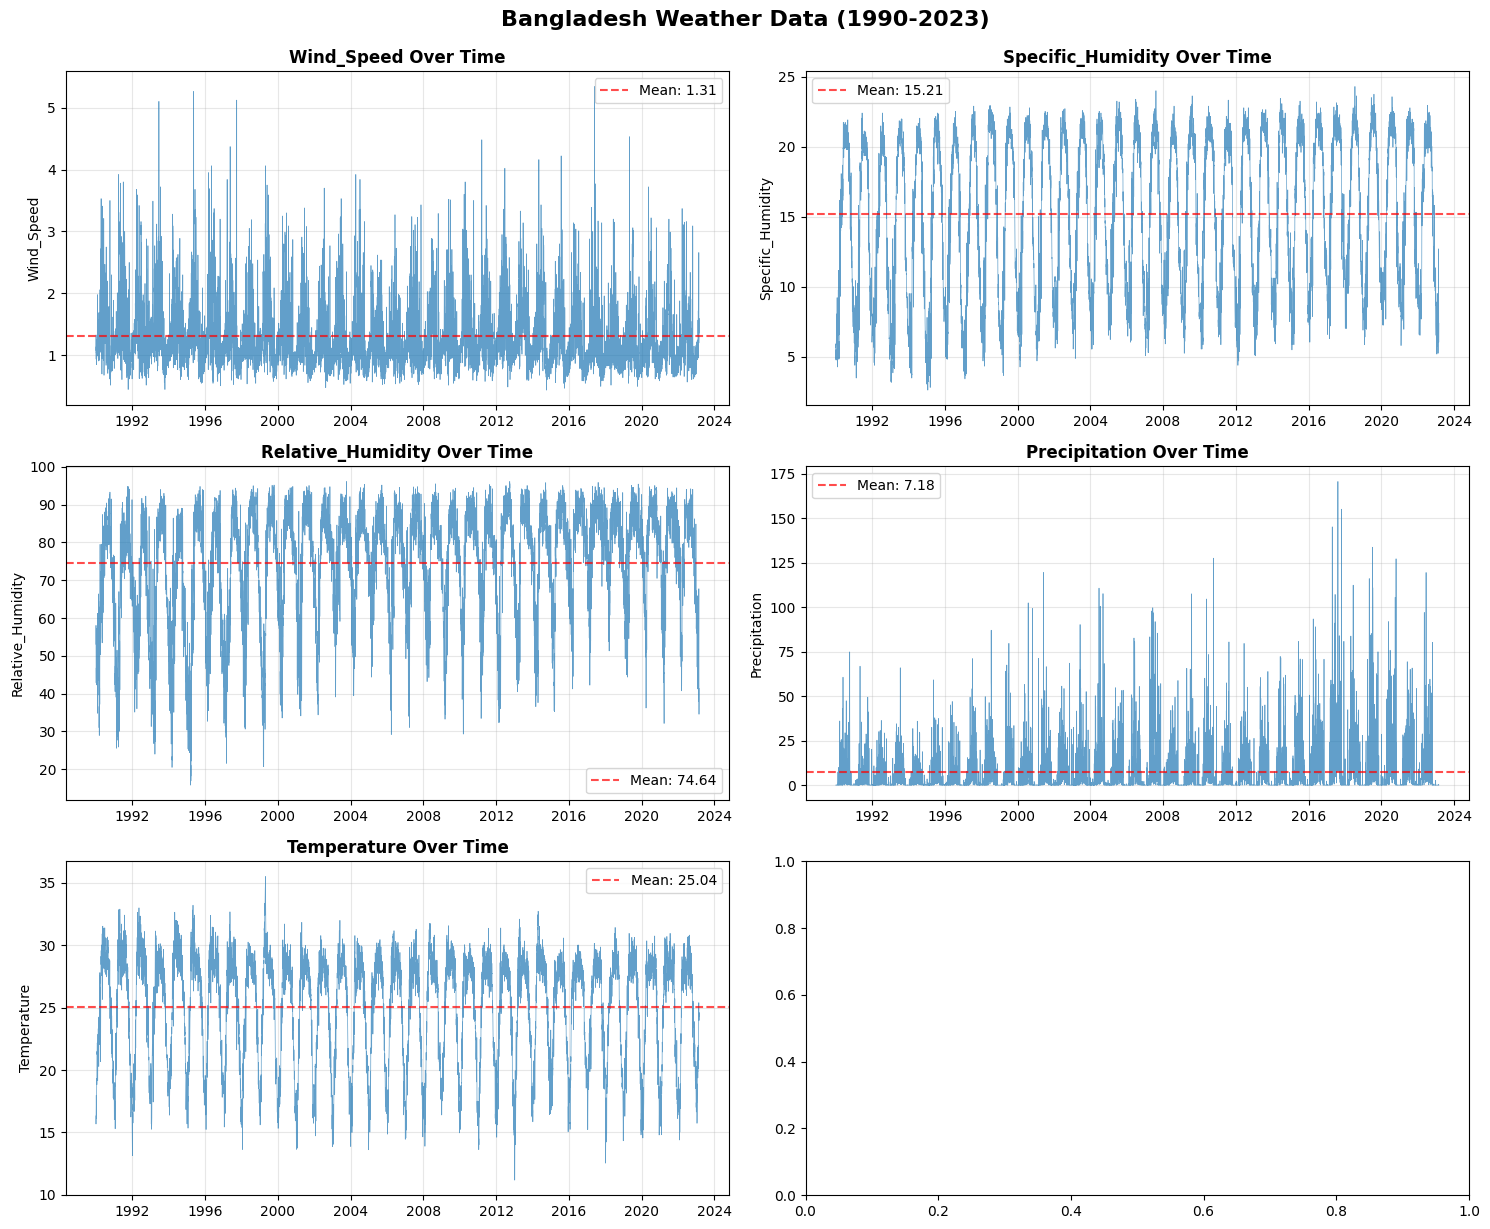

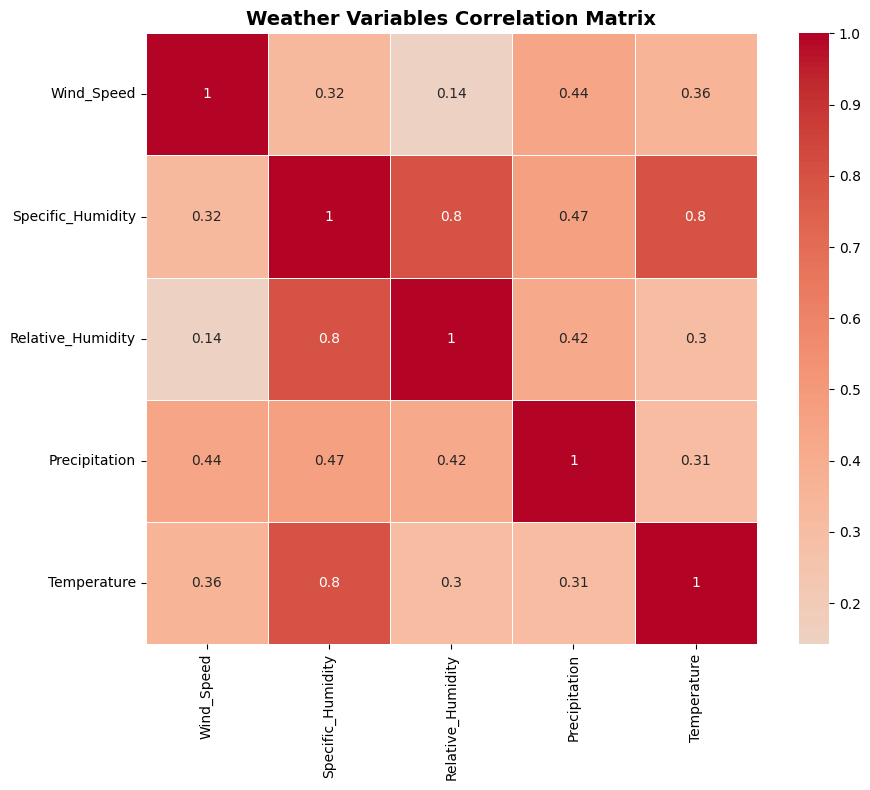

In [9]:
def explore_weather_data(df):
    """
    Comprehensive exploration of weather data
    """

    print("=== BANGLADESH WEATHER DATA EXPLORATION ===")
    print(f"Dataset Shape: {df.shape}")
    print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
    print(f"Total Days: {len(df)} days")
    print(f"Years Covered: {df.index.year.nunique()} years")

    # Basic statistics
    print("\n=== BASIC STATISTICS ===")
    print(df.describe().round(2))

    # Check for missing values
    print("\n=== MISSING VALUES ===")
    missing_values = df.isnull().sum()
    print(missing_values)

    # Data types
    print("\n=== DATA TYPES ===")
    print(df.dtypes)

    # Visualize all weather variables
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        axes[i].plot(df.index, df[column], alpha=0.7, linewidth=0.5)
        axes[i].set_title(f'{column} Over Time', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

        # Add some statistics to the plot
        mean_val = df[column].mean()
        axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend()

    plt.tight_layout()
    plt.suptitle('Bangladesh Weather Data (1990-2023)', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df

# Explore the data
df_explored = explore_weather_data(df)


### 1.3 Data Preprocessing for Simple RNN

#### 1.3.1 Data Cleaning

In [10]:
def clean_weather_data(df):
    """
    Clean the weather data for Simple RNN processing
    """

    print("=== DATA CLEANING PROCESS ===")

    # Make a copy to avoid modifying original data
    df_clean = df.copy()

    # 1. Handle missing values
    print(f"Missing values before cleaning: {df_clean.isnull().sum().sum()}")

    # Forward fill then backward fill for time series data
    df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

    print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

    # 2. Remove outliers using IQR method
    print("\n=== OUTLIER REMOVAL ===")

    for column in df_clean.columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers_before = ((df_clean[column] < lower_bound) |
                          (df_clean[column] > upper_bound)).sum()

        # Remove outliers by clipping
        df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)

        print(f"{column}: {outliers_before} outliers handled")

    # 3. Basic feature engineering for time series
    df_clean['Month'] = df_clean.index.month
    df_clean['Day_of_Year'] = df_clean.index.dayofyear

    # Add simple moving averages (helpful for Simple RNN)
    df_clean['Temp_MA_3'] = df_clean['Temperature'].rolling(window=3).mean()
    df_clean['Temp_MA_7'] = df_clean['Temperature'].rolling(window=7).mean()

    # Remove rows with NaN values created by moving averages
    df_clean.dropna(inplace=True)

    print(f"\nFinal dataset shape: {df_clean.shape}")

    return df_clean

# Clean the data
df_clean = clean_weather_data(df_explored)

=== DATA CLEANING PROCESS ===
Missing values before cleaning: 0
Missing values after cleaning: 0

=== OUTLIER REMOVAL ===
Wind_Speed: 661 outliers handled
Specific_Humidity: 0 outliers handled
Relative_Humidity: 152 outliers handled
Precipitation: 1089 outliers handled
Temperature: 0 outliers handled

Final dataset shape: (12107, 9)


/tmp/ipython-input-601555160.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')


In [11]:
df_clean.head()

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857
1990-01-09,0.85,4.82,42.31,0.0,17.25,1,9,17.603333,17.287143
1990-01-10,1.14,4.76,45.38,0.0,16.33,1,10,17.053333,17.254286
1990-01-11,1.07,5.07,48.44,0.0,16.15,1,11,16.576667,17.120000


#### 1.3.2 Data Normalization (Critical for Simple RNN)


In [12]:
def normalize_data_for_rnn(df, target_column='Temperature'):
    """
    Normalize data for Simple RNN training

    Important: We fit the scaler only on training data to prevent data leakage
    """

    print(f"=== DATA NORMALIZATION FOR SIMPLE RNN ===")
    print(f"Target variable: {target_column}")

    # Separate features and target
    feature_columns = [col for col in df.columns if col != target_column]

    print(f"Feature columns: {feature_columns}")
    print(f"Number of features: {len(feature_columns)}")

    # Initialize scalers
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    return df, feature_columns, feature_scaler, target_scaler

# Prepare for normalization
df_processed, feature_columns, feature_scaler, target_scaler = normalize_data_for_rnn(df_clean)

=== DATA NORMALIZATION FOR SIMPLE RNN ===
Target variable: Temperature
Feature columns: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Number of features: 8


In [13]:
df_processed.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857


These lines are for basic feature engineering in time series analysis, which helps a neural network learn patterns better by adding informative features derived from the raw data.

What are these features?
- Month: The month from each date (e.g., January, February, etc.), which helps encode potential seasonal effects (like monsoons or cold seasons).

- Day_of_Year: The position of each date in the year (e.g., 1 for January 1st, 365 for December 31st), which can capture cyclic trends and annual seasonality.

- Temp_MA_3: The average temperature over the past 3 days for each day.

- Temp_MA_7: The average temperature over the past 7 days for each day.

Why are they done?
- Month and Day_of_Year transform raw date information into numerical features so that machine learning models can learn from seasonal patterns (e.g., temperature might be higher in June than in December).

- Moving averages (Temp_MA_3 and Temp_MA_7) smooth the original temperature signal. They reduce noise and short-term fluctuations, making longer-term trends and cycles more visible for the model. These features help the neural network understand not just today's temperature but also recent context, which is important for forecasting.

Why do we do this for time series models?
- Expose Patterns: Weather data shows seasonal/cyclic behaviors; encoding month and day-of-year helps the model pick up on regular patterns.

- Reduce Noise: Moving averages help to “smooth out” outlier values, giving the model a clearer picture of underlying trends.

Learning Context: RNNs thrive when they can access recent history. Including moving averages lets the model access summarized context of the recent past, not just raw daily values

#### 1.3.3 Time Series Train-Test Split

In [14]:
def create_time_series_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Create time-aware train/validation/test split for time series

    Important: No shuffling to maintain temporal order!
    """

    print(f"=== TIME SERIES DATA SPLITTING ===")

    n_samples = len(df)

    # Calculate split indices
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))

    # Split data maintaining temporal order
    train_data = df.iloc[:train_end].copy()
    val_data = df.iloc[train_end:val_end].copy()
    test_data = df.iloc[val_end:].copy()

    print(f"Training data: {len(train_data)} samples ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Validation data: {len(val_data)} samples ({val_data.index.min()} to {val_data.index.max()})")
    print(f"Test data: {len(test_data)} samples ({test_data.index.min()} to {test_data.index.max()})")

    return train_data, val_data, test_data

# Split the data
train_data, val_data, test_data = create_time_series_split(df_processed)

=== TIME SERIES DATA SPLITTING ===
Training data: 8474 samples (1990-01-07 00:00:00 to 2013-03-20 00:00:00)
Validation data: 1816 samples (2013-03-21 00:00:00 to 2018-03-10 00:00:00)
Test data: 1817 samples (2018-03-11 00:00:00 to 2023-03-01 00:00:00)


In [15]:
train_data.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857


### 1.4 Creating Sequences for Simple RNN

#### Understanding Sequence Creation
Simple RNNs work best with shorter sequences (5-7 days) due to the vanishing gradient problem. Here's how we create sequences:



In [16]:
def create_sequences_for_simple_rnn(features, target, sequence_length=5):
    """
    Create sequences for Simple RNN training

    For Simple RNN, we use shorter sequences (5-7 days) for better performance

    Parameters:
    - data: scaled data array
    - target_column: index of target column
    - sequence_length: number of time steps to look back (keep it short for Simple RNN)
    """

    sequences = []
    targets = []

    # Create sequences
    for i in range(sequence_length, len(features)):
        # Get sequence of past 'sequence_length' days
        sequences.append(features[i-sequence_length:i])  # Shape: (sequence_length, features)

        # Get target (next day's temperature)
        targets.append(target[i])  # Single value

    return np.array(sequences), np.array(targets)

In [17]:
def prepare_data_for_simple_rnn(train_data, val_data, test_data,
                               feature_columns, target_column,
                               feature_scaler, target_scaler,
                               sequence_length=5):
    """
    Complete data preparation pipeline for Simple RNN
    """

    print(f"=== PREPARING DATA FOR SIMPLE RNN ===")
    print(f"Sequence length: {sequence_length} days")
    print(f"Target: {target_column}")
    print(f"Features: {feature_columns}")

    # 1. Scale the data (fit only on training data!)
    train_features_scaled = feature_scaler.fit_transform(train_data[feature_columns])
    train_target_scaled = target_scaler.fit_transform(train_data[[target_column]])
    print(f"Train Target : {train_target_scaled.flatten().shape}")

    val_features_scaled = feature_scaler.transform(val_data[feature_columns])
    val_target_scaled = target_scaler.transform(val_data[[target_column]])

    test_features_scaled = feature_scaler.transform(test_data[feature_columns])
    test_target_scaled = target_scaler.transform(test_data[[target_column]])

    # 2. Combine features and target for sequence creation
    train_combined = np.column_stack([train_features_scaled, train_target_scaled])
    val_combined = np.column_stack([val_features_scaled, val_target_scaled])
    test_combined = np.column_stack([test_features_scaled, test_target_scaled])

    # 3. Find target column index in combined array
    #target_idx = train_data.columns.get_loc('Temperature')

    # 4. Create sequences
    X_train, y_train = create_sequences_for_simple_rnn(train_features_scaled, train_target_scaled.flatten(), sequence_length)
    X_val, y_val = create_sequences_for_simple_rnn(val_features_scaled, val_target_scaled.flatten(), sequence_length)
    X_test, y_test = create_sequences_for_simple_rnn(test_features_scaled, test_target_scaled.flatten(), sequence_length)


    print(f"Training sequences: {X_train.shape}")
    print(f"Training targets: {y_train.shape}")
    print(f"Validation sequences: {X_val.shape}")
    print(f"Test sequences: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# Prepare sequences (using short sequence length for Simple RNN)
SEQUENCE_LENGTH = 5  # Only 5 days - optimal for Simple RNN

(X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_for_simple_rnn(
    train_data, val_data, test_data,
    feature_columns, 'Temperature',
    feature_scaler, target_scaler,
    sequence_length=SEQUENCE_LENGTH
)

print("Data preparation completed successfully!")

=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8469, 5, 8)
Training targets: (8469,)
Validation sequences: (1811, 5, 8)
Test sequences: (1812, 5, 8)
Data preparation completed successfully!


In [18]:
X_train[100]

array([[0.53506494, 0.59709874, 0.48388637, 0.04406048, 0.27272727,
        0.29041096, 0.74475574, 0.72374025],
       [1.        , 0.60832943, 0.50473462, 0.15809935, 0.27272727,
        0.29315068, 0.74292552, 0.73180001],
       [1.        , 0.59709874, 0.49980107, 0.21900648, 0.27272727,
        0.29589041, 0.73363368, 0.7322587 ],
       [1.        , 0.68834815, 0.65401448, 0.81382289, 0.27272727,
        0.29863014, 0.71913276, 0.72564052],
       [1.        , 0.72297613, 0.73645261, 1.        , 0.27272727,
        0.30136986, 0.69815571, 0.71993972]])

### 1.5 Building Simple RNN Model

#### 1.5.1 Understanding Simple RNN Architecture

In [19]:
def create_simple_rnn_model(input_shape, hidden_units=32, dropout_rate=0.2):
    """
    Create a Simple RNN model optimized for weather prediction

    Architecture:
    1. SimpleRNN layer with specified hidden units
    2. Dropout for regularization
    3. Dense layer for final prediction

    Parameters:
    - input_shape: (sequence_length, number_of_features)
    - hidden_units: number of neurons in RNN layer
    - dropout_rate: dropout rate for regularization
    """

    print(f"=== BUILDING SIMPLE RNN MODEL ===")
    print(f"Input shape: {input_shape}")
    print(f"Hidden units: {hidden_units}")
    print(f"Dropout rate: {dropout_rate}")

    model = Sequential(name="Simple_RNN_Weather_Predictor")

    # Add Input layer to specify input shape
    model.add(Input(shape=input_shape, name='Input_Layer'))

    # Add SimpleRNN layer without input_shape argument
    model.add(SimpleRNN(
        units=hidden_units,
        activation='tanh',  # Default activation
        dropout=dropout_rate,
        recurrent_dropout=dropout_rate,
        name='SimpleRNN_Layer'
    ))


    # Add dropout for additional regularization
    model.add(Dropout(dropout_rate, name='Dropout_Layer'))

    # Add dense layer for final prediction
    model.add(Dense(
        units=1,
        activation='linear',  # Linear activation for regression
        name='Output_Layer'
    ))

    # Compile the model
    optimizer = Adam(learning_rate=0.001)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mean_absolute_error', 'mean_absolute_percentage_error']
    )

    # Display model summary
    print("\n=== MODEL ARCHITECTURE ===")
    model.summary()

    return model

# Create the Simple RNN model
input_shape = (X_train.shape[1], X_train.shape[2])  # (sequence_length, features)
model = create_simple_rnn_model(input_shape, hidden_units=32, dropout_rate=0.2)

=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 8)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.5.2 Model Training Strategy

In [20]:
def train_simple_rnn_model(model, X_train, y_train, X_val, y_val,
                          epochs=100, batch_size=32, patience=10):
    """
    Train Simple RNN model with proper callbacks

    Simple RNN training considerations:
    - Lower epochs (50) due to faster convergence
    - Early stopping to prevent overfitting
    - Learning rate reduction for better convergence
    """

    print(f"=== TRAINING SIMPLE RNN MODEL ===")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Epochs: {epochs}")
    print(f"Batch size: {batch_size}")

    # Define callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        ModelCheckpoint(
            'best_simple_rnn_model.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # Train the model
    print("\nStarting training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Important: Don't shuffle time series data
    )

    print("Training completed!")
    return history

# Train the model
training_history = train_simple_rnn_model(
    model, X_train, y_train, X_val, y_val,
    epochs=100, batch_size=32, patience=10
)


=== TRAINING SIMPLE RNN MODEL ===
Training samples: 8469
Validation samples: 1811
Epochs: 100
Batch size: 32

Starting training...
Epoch 1/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2801 - mean_absolute_error: 0.4057 - mean_absolute_percentage_error: 798.7505
Epoch 1: val_loss improved from inf to 0.00661, saving model to best_simple_rnn_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.2797 - mean_absolute_error: 0.4054 - mean_absolute_percentage_error: 1034.1366 - val_loss: 0.0066 - val_mean_absolute_error: 0.0629 - val_mean_absolute_percentage_error: 14.2827
Epoch 2/100
262/265 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0607 - mean_absolute_error: 0.1942 - mean_absolute_percentage_error: 37.0050
Epoch 2: val_loss improved from 0.00661 to 0.00565, saving model to best_simple_rnn_model.h5


265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0606 - mean_absolute_error: 0.1940 - mean_absolute_percentage_error: 593.6099 - val_loss: 0.0056 - val_mean_absolute_error: 0.0576 - val_mean_absolute_percentage_error: 13.6068
Epoch 3/100
264/265 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0385 - mean_absolute_error: 0.1541 - mean_absolute_percentage_error: 359.4192
Epoch 3: val_loss did not improve from 0.00565
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0384 - mean_absolute_error: 0.1540 - mean_absolute_percentage_error: 682.3739 - val_loss: 0.0057 - val_mean_absolute_error: 0.0583 - val_mean_absolute_percentage_error: 13.6828
Epoch 4/100
257/265 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0293 - mean_absolute_error: 0.1360 - mean_absolute_percentage_error: 27.3616
Epoch 4: val_loss did not improve from 0.00565
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0292 - mean_absolute_error: 0.1359 - mean_absolute_percentage_error: 668.9738 - val_loss: 0.0059 - val_mean_absolute_

### 1.6 Model Evaluation and Visualization

#### 1.6.1 Training History Visualization

=== TRAINING HISTORY VISUALIZATION ===


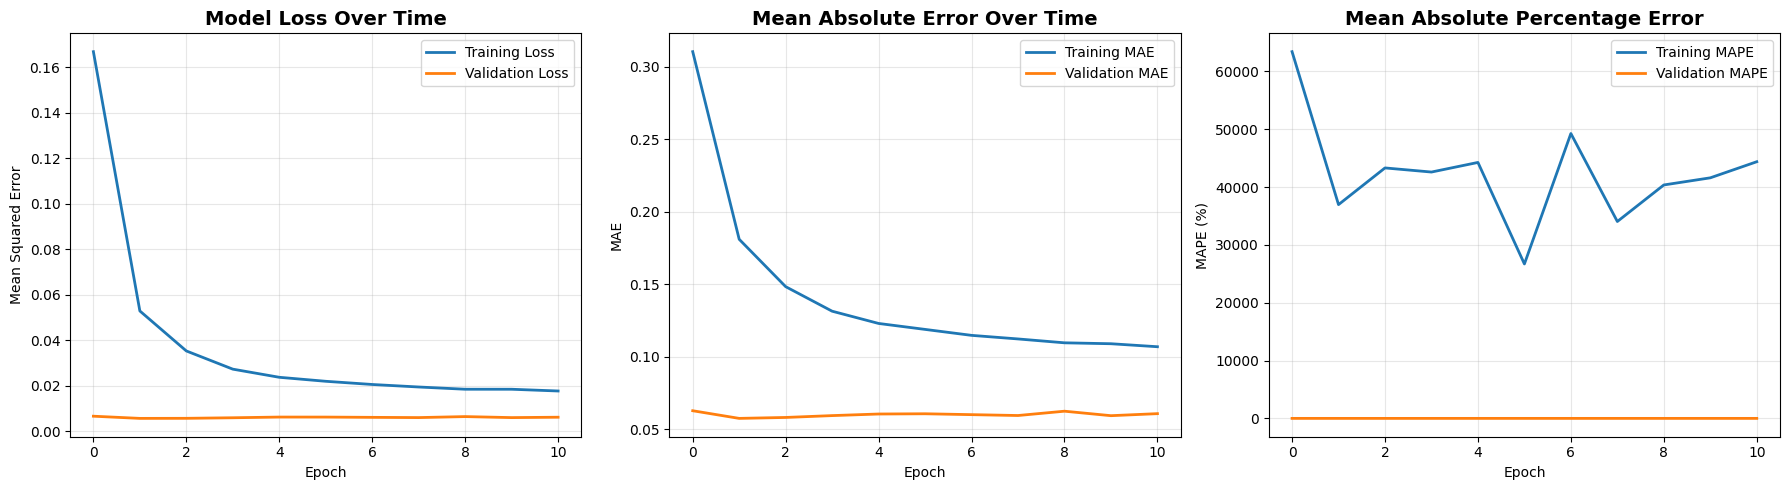

In [21]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Visualize training history for Simple RNN
    """

    print("=== TRAINING HISTORY VISUALIZATION ===")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2)
    axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2)
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # MAPE plot
    axes[2].plot(history.history['mean_absolute_percentage_error'],
                label='Training MAPE', linewidth=2)
    axes[2].plot(history.history['val_mean_absolute_percentage_error'],
                label='Validation MAPE', linewidth=2)
    axes[2].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(training_history)

#### 1.6.2 Model Performance Evaluation

In [22]:
def evaluate_simple_rnn_performance(model, X_test, y_test, target_scaler):
    """
    Comprehensive evaluation of Simple RNN performance
    """

    print("=== SIMPLE RNN MODEL EVALUATION ===")

    # Make predictions
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)

    # Calculate MAPE manually
    mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

    # Temperature-specific accuracy (within certain degrees)
    accuracy_1deg = np.mean(np.abs(y_test_original - y_pred_original) <= 1.0) * 100
    accuracy_2deg = np.mean(np.abs(y_test_original - y_pred_original) <= 2.0) * 100
    accuracy_3deg = np.mean(np.abs(y_test_original - y_pred_original) <= 3.0) * 100

    # Print results
    print("\n🌤️  SIMPLE RNN WEATHER PREDICTION RESULTS 🌤️")
    print("=" * 55)
    print(f"📊 Mean Squared Error (MSE):      {mse:.4f}")
    print(f"📊 Root Mean Squared Error (RMSE): {rmse:.4f}°C")
    print(f"📊 Mean Absolute Error (MAE):     {mae:.4f}°C")
    print(f"📊 R-squared Score (R²):          {r2:.4f}")
    print(f"📊 Mean Absolute Percentage Error: {mape:.2f}%")
    print("=" * 55)
    print("🎯 TEMPERATURE PREDICTION ACCURACY:")
    print(f"   Within ±1°C: {accuracy_1deg:.1f}% of predictions")
    print(f"   Within ±2°C: {accuracy_2deg:.1f}% of predictions")
    print(f"   Within ±3°C: {accuracy_3deg:.1f}% of predictions")
    print("=" * 55)

    return {
        'y_true': y_test_original,
        'y_pred': y_pred_original,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape,
        'accuracy_1deg': accuracy_1deg,
        'accuracy_2deg': accuracy_2deg,
        'accuracy_3deg': accuracy_3deg
    }

# Evaluate the model
evaluation_results = evaluate_simple_rnn_performance(model, X_test, y_test, target_scaler)

=== SIMPLE RNN MODEL EVALUATION ===

🌤️  SIMPLE RNN WEATHER PREDICTION RESULTS 🌤️
📊 Mean Squared Error (MSE):      3.9997
📊 Root Mean Squared Error (RMSE): 1.9999°C
📊 Mean Absolute Error (MAE):     1.5756°C
📊 R-squared Score (R²):          0.7859
📊 Mean Absolute Percentage Error: 6.96%
🎯 TEMPERATURE PREDICTION ACCURACY:
   Within ±1°C: 40.3% of predictions
   Within ±2°C: 69.3% of predictions
   Within ±3°C: 86.9% of predictions


#### 1.6.3 Prediction Visualization

=== PREDICTION VISUALIZATION ===


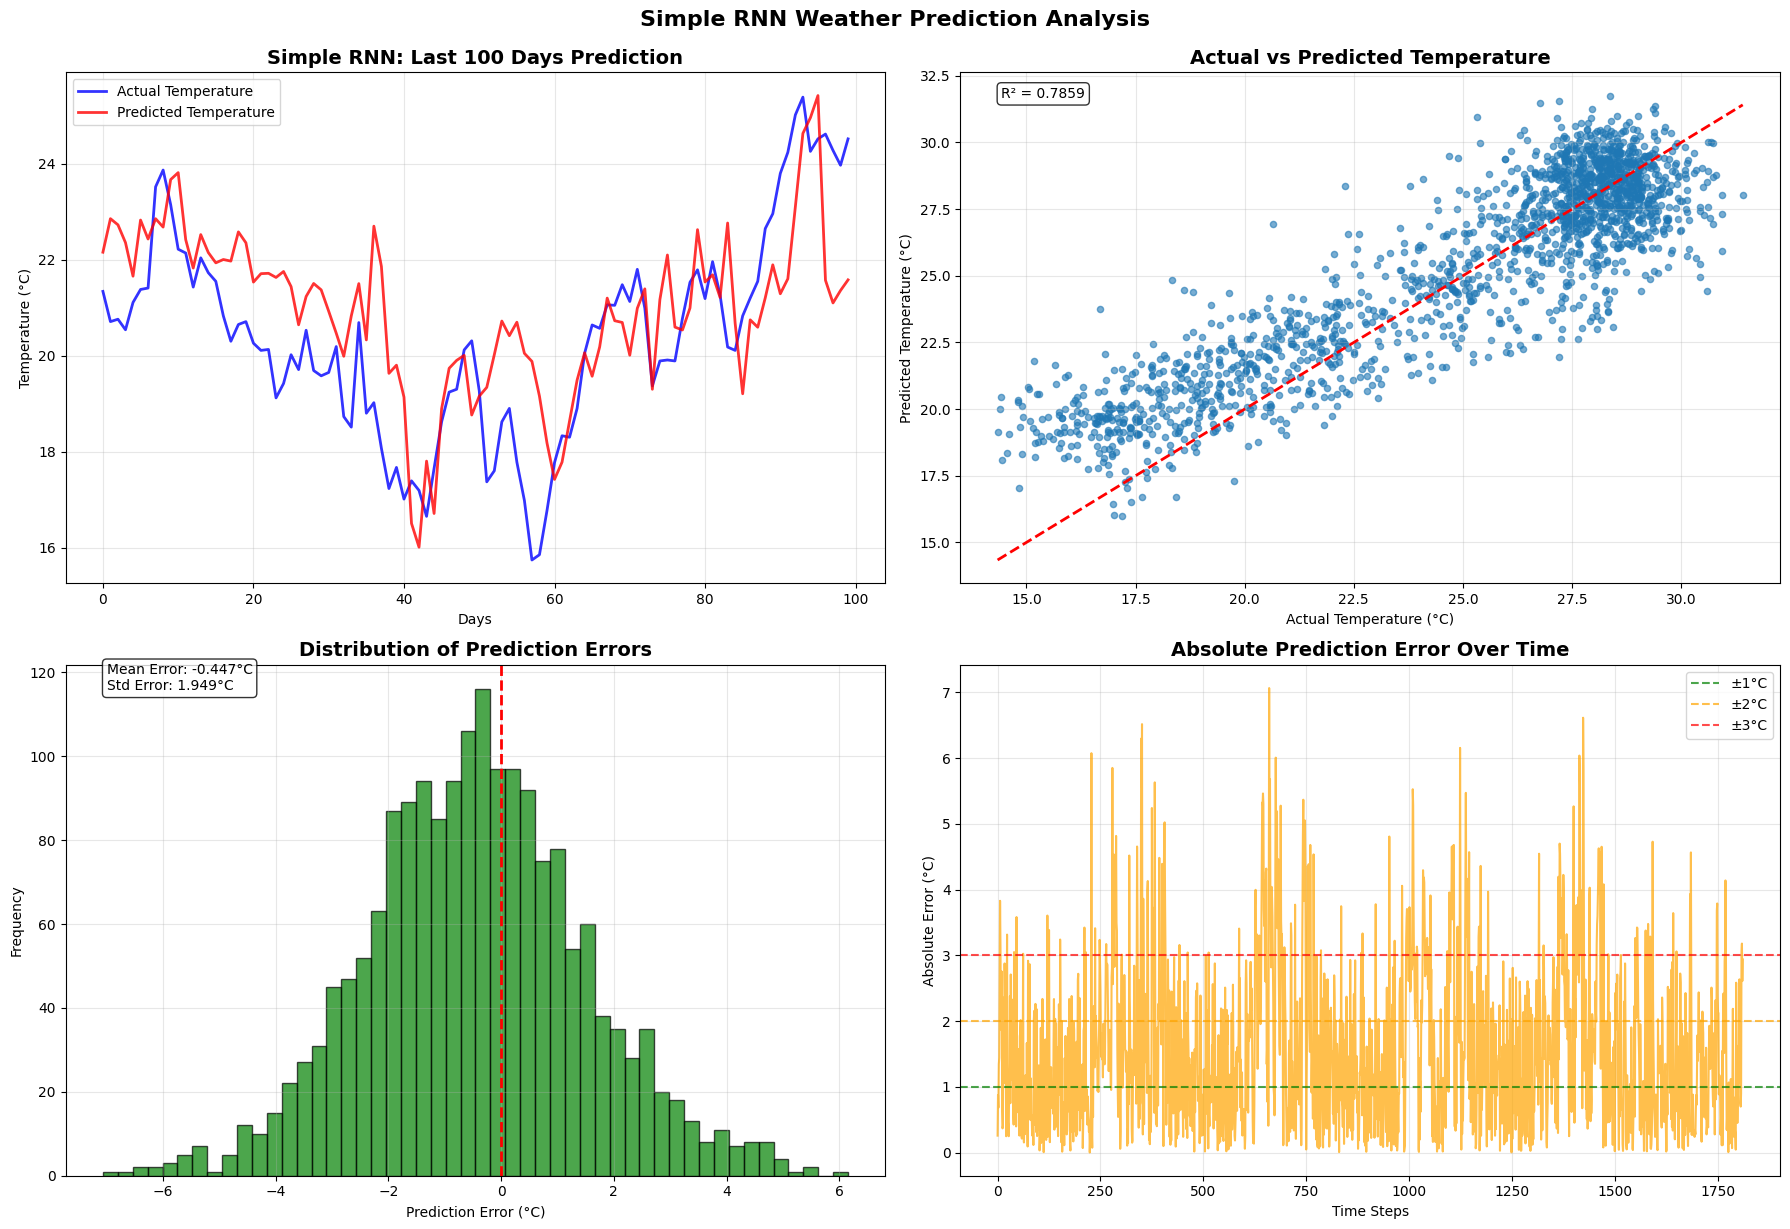

In [23]:
def visualize_predictions(results, days_to_show=100):
    """
    Create comprehensive visualizations of Simple RNN predictions
    """

    print(f"=== PREDICTION VISUALIZATION ===")

    y_true = results['y_true']
    y_pred = results['y_pred']

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Time series plot (last N days)
    axes[0, 0].plot(y_true[-days_to_show:], label='Actual Temperature',
                   linewidth=2, alpha=0.8, color='blue')
    axes[0, 0].plot(y_pred[-days_to_show:], label='Predicted Temperature',
                   linewidth=2, alpha=0.8, color='red')
    axes[0, 0].set_title(f'Simple RNN: Last {days_to_show} Days Prediction',
                        fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Days')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Scatter plot: Actual vs Predicted
    axes[0, 1].scatter(y_true, y_pred, alpha=0.6, s=20)
    min_temp, max_temp = y_true.min(), y_true.max()
    axes[0, 1].plot([min_temp, max_temp], [min_temp, max_temp], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Temperature (°C)')
    axes[0, 1].set_ylabel('Predicted Temperature (°C)')
    axes[0, 1].set_title('Actual vs Predicted Temperature', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # Add R² to scatter plot
    r2 = results['r2']
    axes[0, 1].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3. Error distribution
    errors = y_true - y_pred
    axes[1, 0].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Prediction Error (°C)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Add error statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    axes[1, 0].text(0.05, 0.95, f'Mean Error: {mean_error:.3f}°C\nStd Error: {std_error:.3f}°C',
                   transform=axes[1, 0].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Error over time
    axes[1, 1].plot(np.abs(errors), alpha=0.7, color='orange')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Absolute Error (°C)')
    axes[1, 1].set_title('Absolute Prediction Error Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    # Add horizontal lines for accuracy thresholds
    axes[1, 1].axhline(1, color='green', linestyle='--', alpha=0.7, label='±1°C')
    axes[1, 1].axhline(2, color='orange', linestyle='--', alpha=0.7, label='±2°C')
    axes[1, 1].axhline(3, color='red', linestyle='--', alpha=0.7, label='±3°C')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.suptitle('Simple RNN Weather Prediction Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Visualize predictions
visualize_predictions(evaluation_results, days_to_show=100)


#### 1.6.4 Real-time Prediction Function

In [24]:
def make_weather_prediction(model, recent_data, feature_scaler, target_scaler,
                           feature_columns, sequence_length=5):
    """
    Make a weather prediction using the trained Simple RNN model

    Parameters:
    - model: trained Simple RNN model
    - recent_data: pandas DataFrame with recent weather data (last 'sequence_length' days)
    - feature_scaler: fitted feature scaler
    - target_scaler: fitted target scaler
    - feature_columns: list of feature column names
    - sequence_length: number of days to use for prediction
    """

    print(f"=== MAKING NEW WEATHER PREDICTION ===")

    if len(recent_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} days of recent data")

    # Get the last sequence_length days
    recent_sequence = recent_data[feature_columns].iloc[-sequence_length-1:-1].values

    # Scale the data
    #recent_sequence_scaled = feature_scaler.transform(recent_sequence)

    #Convert recent_sequence (numpy array) back to DataFrame with columns for scaler
    recent_sequence_df = pd.DataFrame(recent_sequence, columns=feature_columns)
    print(recent_sequence_df)


    # Now transform with feature scaler (which expects column names)
    recent_sequence_scaled = feature_scaler.transform(recent_sequence_df)

    # Reshape for model input: (1, sequence_length, features)
    input_sequence = recent_sequence_scaled.reshape(1, sequence_length, -1)

    # Make prediction (scaled)
    prediction_scaled = model.predict(input_sequence, verbose=0)

    # Inverse transform to get actual temperature
    predicted_temp = target_scaler.inverse_transform(prediction_scaled)[0, 0]

    print(f"🌡️  Predicted temperature for tomorrow: {predicted_temp:.2f}°C")

    return predicted_temp

# Example: Make prediction using last 5 days of test data
sample_recent_data = test_data.iloc[-10:]  # Last 10 days as example
prediction = make_weather_prediction(
    model, sample_recent_data, feature_scaler, target_scaler,
    feature_columns, sequence_length=SEQUENCE_LENGTH
)


=== MAKING NEW WEATHER PREDICTION ===
   Wind_Speed  Specific_Humidity  Relative_Humidity  Precipitation  Month  \
0        1.20              12.15              67.75           0.37    2.0   
1        1.28               8.85              50.44           0.00    2.0   
2        1.41               6.59              38.06           0.00    2.0   
3        1.60               6.04              34.56           0.00    2.0   
4        1.49               6.65              38.94           0.00    2.0   

   Day_of_Year  Temp_MA_3  Temp_MA_7  
0         55.0  24.890000  24.045714  
1         56.0  24.723333  24.312857  
2         57.0  24.466667  24.550000  
3         58.0  24.473333  24.618571  
4         59.0  24.290000  24.580000  
🌡️  Predicted temperature for tomorrow: 21.58°C


In [25]:
df_clean.tail(5)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
2023-02-25,1.28,8.85,50.44,0.0,24.52,2,56,24.723333,24.312857
2023-02-26,1.41,6.59,38.06,0.0,24.62,2,57,24.466667,24.550000
2023-02-27,1.60,6.04,34.56,0.0,24.28,2,58,24.473333,24.618571
2023-02-28,1.49,6.65,38.94,0.0,23.97,2,59,24.290000,24.580000
2023-03-01,1.36,7.39,41.38,0.0,24.52,3,60,24.256667,24.508571


In [26]:
print(f"Actual Temperture value of last data: {df_clean.tail(5)['Temperature'].values[-1]}")

Actual Temperture value of last data: 24.52


### Understanding Simple RNN Limitations

In [27]:
def analyze_simple_rnn_limitations():
    """
    Educational analysis of Simple RNN limitations for students
    """

    print("=== UNDERSTANDING SIMPLE RNN LIMITATIONS ===")
    print("\n WHY SIMPLE RNN HAS LIMITATIONS:")
    print("=" * 50)

    print("1. VANISHING GRADIENT PROBLEM:")
    print("   - Gradients become very small as they propagate back through time")
    print("   - Model struggles to learn from events more than 5-10 time steps ago")
    print("   - Weather patterns often require longer memory (weeks/months)")

    print("\n2. SHORT-TERM MEMORY:")
    print("   - Simple RNN forgets information from distant past quickly")
    print("   - Weather has seasonal patterns that need long-term memory")
    print("   - Best performance with 3-7 day sequences")

    print("\n3. PERFORMANCE COMPARISON:")
    print("   - Simple RNN: Good for short-term patterns")
    print("   - LSTM/GRU: Better for long-term dependencies")
    print("   - Complex weather patterns need advanced models")

    print("\n WHEN TO USE SIMPLE RNN:")
    print("   Learning RNN fundamentals")
    print("   Short-term predictions (1-3 days)")
    print("   Simple patterns and trends")
    print("   Computational resource constraints")
    print("   Proof of concept projects")

    print("\n NEXT STEPS FOR STUDENTS:")
    print("   1. Master Simple RNN concepts")
    print("   2. Learn LSTM architecture")
    print("   3. Compare performance differences")
    print("   4. Understand when to use each model")
    print("=" * 50)

# Run the educational analysis
analyze_simple_rnn_limitations()

=== UNDERSTANDING SIMPLE RNN LIMITATIONS ===

 WHY SIMPLE RNN HAS LIMITATIONS:
1. VANISHING GRADIENT PROBLEM:
   - Gradients become very small as they propagate back through time
   - Model struggles to learn from events more than 5-10 time steps ago
   - Weather patterns often require longer memory (weeks/months)

2. SHORT-TERM MEMORY:
   - Simple RNN forgets information from distant past quickly
   - Weather has seasonal patterns that need long-term memory
   - Best performance with 3-7 day sequences

3. PERFORMANCE COMPARISON:
   - Simple RNN: Good for short-term patterns
   - LSTM/GRU: Better for long-term dependencies
   - Complex weather patterns need advanced models

 WHEN TO USE SIMPLE RNN:
   Learning RNN fundamentals
   Short-term predictions (1-3 days)
   Simple patterns and trends
   Computational resource constraints
   Proof of concept projects

 NEXT STEPS FOR STUDENTS:
   1. Master Simple RNN concepts
   2. Learn LSTM architecture
   3. Compare performance differences
 

### Student Exercises

In [28]:
def student_exercises():
    """
    Hands-on exercises for students to reinforce learning
    """

    print(" STUDENT EXERCISES - SIMPLE RNN WEATHER PREDICTION")
    print("=" * 60)

    exercises = [
        {
            "title": "Exercise 1: Experiment with Sequence Length",
            "description": "Try different sequence lengths (3, 5, 7, 10) and observe performance changes",
            "code_hint": "modify sequence_length parameter in prepare_data_for_simple_rnn()",
            "expected_outcome": "Understand how sequence length affects Simple RNN performance"
        },
        {
            "title": "Exercise 2: Change Hidden Units",
            "description": "Test different hidden layer sizes (16, 32, 64, 128)",
            "code_hint": "modify hidden_units parameter in create_simple_rnn_model()",
            "expected_outcome": "Learn about model capacity and overfitting"
        },
        {
            "title": "Exercise 3: Feature Selection",
            "description": "Try using different combinations of weather features",
            "code_hint": "modify feature_columns list before training",
            "expected_outcome": "Understand which features are most important for prediction"
        },
        {
            "title": "Exercise 4: Predict Different Variables",
            "description": "Try predicting humidity or wind speed instead of temperature",
            "code_hint": "change target_column parameter to 'Relative_Humidity' or 'Wind_Speed'",
            "expected_outcome": "See how model performs on different weather variables"
        },
        {
            "title": "Exercise 5: Error Analysis",
            "description": "Identify when the model makes the largest errors",
            "code_hint": "analyze prediction errors by season or weather conditions",
            "expected_outcome": "Understand model limitations and failure cases"
        }
    ]

    for i, exercise in enumerate(exercises, 1):
        print(f"\n {exercise['title']}")
        print(f"    Task: {exercise['description']}")
        print(f"    Hint: {exercise['code_hint']}")
        print(f"    Goal: {exercise['expected_outcome']}")

    print("\n" + "=" * 60)
    print(" Remember: Simple RNN is a stepping stone to advanced models!")

# Display exercises
student_exercises()


 STUDENT EXERCISES - SIMPLE RNN WEATHER PREDICTION

 Exercise 1: Experiment with Sequence Length
    Task: Try different sequence lengths (3, 5, 7, 10) and observe performance changes
    Hint: modify sequence_length parameter in prepare_data_for_simple_rnn()
    Goal: Understand how sequence length affects Simple RNN performance

 Exercise 2: Change Hidden Units
    Task: Test different hidden layer sizes (16, 32, 64, 128)
    Hint: modify hidden_units parameter in create_simple_rnn_model()
    Goal: Learn about model capacity and overfitting

 Exercise 3: Feature Selection
    Task: Try using different combinations of weather features
    Hint: modify feature_columns list before training
    Goal: Understand which features are most important for prediction

 Exercise 4: Predict Different Variables
    Task: Try predicting humidity or wind speed instead of temperature
    Hint: change target_column parameter to 'Relative_Humidity' or 'Wind_Speed'
    Goal: See how model performs on di

### Exercises Implementation

In [ ]:
# STUDENT EXERCISES IMPLEMENTATION

print("🎓 IMPLEMENTING STUDENT EXERCISES FOR SIMPLE RNN")
print("=" * 60)

# ========================================
# EXERCISE 1: EXPERIMENT WITH SEQUENCE LENGTH
# ========================================

print("\n EXERCISE 1: Experimenting with Different Sequence Lengths")
print("-" * 50)

def exercise_1_sequence_length_experiment():
    """
    Test different sequence lengths and compare performance
    """
    sequence_lengths = [3, 5, 7, 10]
    results = {}

    for seq_len in sequence_lengths:
        print(f"\n Testing sequence length: {seq_len}")

        # Prepare data with different sequence length
        (X_train_ex, y_train_ex), (X_val_ex, y_val_ex), (X_test_ex, y_test_ex) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            feature_columns, 'Temperature',
            feature_scaler, target_scaler,
            sequence_length=seq_len
        )

        # Create model
        input_shape_ex = (X_train_ex.shape[1], X_train_ex.shape[2])
        model_ex = create_simple_rnn_model(input_shape_ex, hidden_units=32, dropout_rate=0.2)

        # Train model (fewer epochs for comparison)
        history_ex = model_ex.fit(
            X_train_ex, y_train_ex,
            validation_data=(X_val_ex, y_val_ex),
            epochs=20,  # Reduced for faster comparison
            batch_size=32,
            verbose=0
        )

        # Evaluate
        y_pred_ex = model_ex.predict(X_test_ex, verbose=0)
        y_test_orig = target_scaler.inverse_transform(y_test_ex.reshape(-1, 1)).flatten()
        y_pred_orig = target_scaler.inverse_transform(y_pred_ex).flatten()

        mae = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

        results[seq_len] = {
            'mae': mae,
            'rmse': rmse,
            'final_val_loss': history_ex.history['val_loss'][-1]
        }

        print(f"   MAE: {mae:.4f}°C")
        print(f"   RMSE: {rmse:.4f}°C")

    # Summary
    print(f"\n📊 SEQUENCE LENGTH COMPARISON RESULTS:")
    print("Seq Length | MAE (°C) | RMSE (°C) | Val Loss")
    print("-" * 45)
    for seq_len, result in results.items():
        print(f"    {seq_len:2d}     |  {result['mae']:6.4f}  |  {result['rmse']:7.4f}  | {result['final_val_loss']:8.6f}")

    # Find best
    best_seq_len = min(results.keys(), key=lambda x: results[x]['mae'])
    print(f"\n Best sequence length: {best_seq_len} days (lowest MAE)")

    return results

# Run Exercise 1
exercise_1_results = exercise_1_sequence_length_experiment()

🎓 IMPLEMENTING STUDENT EXERCISES FOR SIMPLE RNN

📚 EXERCISE 1: Experimenting with Different Sequence Lengths
--------------------------------------------------

🔬 Testing sequence length: 3
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 3 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8471, 3, 8)
Training targets: (8471,)
Validation sequences: (1813, 3, 8)
Test sequences: (1814, 3, 8)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (3, 8)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

   MAE: 1.2264°C
   RMSE: 1.6248°C

📊 SEQUENCE LENGTH COMPARISON RESULTS:
Seq Length | MAE (°C) | RMSE (°C) | Val Loss
---------------------------------------------
     3     |  1.2017  |   1.6109  | 0.003706
     5     |  1.2511  |   1.7075  | 0.004560
     7     |  1.2966  |   1.7564  | 0.004856
    10     |  1.2264  |   1.6248  | 0.004331

🏆 Best sequence length: 3 days (lowest MAE)


In [ ]:
# ========================================
# EXERCISE 2: CHANGE HIDDEN UNITS
# ========================================

print("\n\n EXERCISE 2: Experimenting with Different Hidden Unit Sizes")
print("-" * 50)

def exercise_2_hidden_units_experiment():
    """
    Test different hidden layer sizes and observe performance vs complexity
    """
    hidden_units_list = [16, 32, 64, 128]
    results = {}

    # First, prepare data with consistent feature set for all experiments
    print("Preparing data for hidden units experiment...")
    print(f"Using features: {feature_columns}")
    print(f"Number of features: {len(feature_columns)}")

    (X_train_ex2, y_train_ex2), (X_val_ex2, y_val_ex2), (X_test_ex2, y_test_ex2) = prepare_data_for_simple_rnn(
        train_data, val_data, test_data,
        feature_columns, 'Temperature',
        feature_scaler, target_scaler,
        sequence_length=5
    )

    print(f"Data shapes: X_train={X_train_ex2.shape}, y_train={y_train_ex2.shape}")

    for hidden_units in hidden_units_list:
        print(f"\n Testing hidden units: {hidden_units}")

        # Create model with different hidden units
        input_shape_ex = (X_train_ex2.shape[1], X_train_ex2.shape[2])
        print(f"   Input shape: {input_shape_ex}")
        model_ex = create_simple_rnn_model(input_shape_ex, hidden_units=hidden_units, dropout_rate=0.2)

        # Count parameters
        total_params = model_ex.count_params()
        print(f"   Total parameters: {total_params:,}")

        # Train model
        history_ex = model_ex.fit(
            X_train_ex2, y_train_ex2,
            validation_data=(X_val_ex2, y_val_ex2),
            epochs=25,  # Reduced for comparison
            batch_size=32,
            verbose=0
        )

        # Evaluate
        y_pred_ex = model_ex.predict(X_test_ex2, verbose=0)
        y_test_orig = target_scaler.inverse_transform(y_test_ex2.reshape(-1, 1)).flatten()
        y_pred_orig = target_scaler.inverse_transform(y_pred_ex).flatten()

        mae = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
        r2 = r2_score(y_test_orig, y_pred_orig)

        # Check for overfitting
        train_loss = history_ex.history['loss'][-1]
        val_loss = history_ex.history['val_loss'][-1]
        overfitting_ratio = val_loss / train_loss

        results[hidden_units] = {
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'params': total_params,
            'overfitting_ratio': overfitting_ratio,
            'train_loss': train_loss,
            'val_loss': val_loss
        }

        print(f"   MAE: {mae:.4f}°C")
        print(f"   RMSE: {rmse:.4f}°C")
        print(f"   R²: {r2:.4f}")
        print(f"   Overfitting ratio: {overfitting_ratio:.3f}")

    # Summary
    print(f"\n📊 HIDDEN UNITS COMPARISON RESULTS:")
    print("Hidden Units | Parameters | MAE (°C) | RMSE (°C) | R²     | Overfitting")
    print("-" * 75)
    for units, result in results.items():
        print(f"    {units:3d}      |  {result['params']:8,} | {result['mae']:7.4f}  |  {result['rmse']:7.4f}  | {result['r2']:6.4f} |    {result['overfitting_ratio']:5.3f}")

    # Analysis
    best_mae = min(results.keys(), key=lambda x: results[x]['mae'])
    best_r2 = max(results.keys(), key=lambda x: results[x]['r2'])
    least_overfit = min(results.keys(), key=lambda x: results[x]['overfitting_ratio'])

    print(f"\n Best MAE: {best_mae} units")
    print(f" Best R²: {best_r2} units")
    print(f" Least overfitting: {least_overfit} units")

    return results

# Run Exercise 2
exercise_2_results = exercise_2_hidden_units_experiment()



📚 EXERCISE 2: Experimenting with Different Hidden Unit Sizes
--------------------------------------------------
Preparing data for hidden units experiment...
Using features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Number of features: 8
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8469, 5, 8)
Training targets: (8469,)
Validation sequences: (1811, 5, 8)
Test sequences: (1812, 5, 8)
Data shapes: X_train=(8469, 5, 8), y_train=(8469,)

🔬 Testing hidden units: 16
   Input shape: (5, 8)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 8)
Hidden units: 16
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 128)            │        17,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,665 (69.00 KB)

 Trainable params: 17,665 (69.00 KB)

 Non-trainable params: 0 (0.00 B)

   Total parameters: 17,665
   MAE: 1.3182°C
   RMSE: 1.6155°C
   R²: 0.8603
   Overfitting ratio: 0.695

📊 HIDDEN UNITS COMPARISON RESULTS:
Hidden Units | Parameters | MAE (°C) | RMSE (°C) | R²     | Overfitting
---------------------------------------------------------------------------
     16      |       417 |  1.2978  |   1.7770  | 0.8310 |    0.400
     32      |     1,345 |  1.1819  |   1.6388  | 0.8563 |    0.369
     64      |     4,737 |  1.0468  |   1.4073  | 0.8940 |    0.329
    128      |    17,665 |  1.3182  |   1.6155  | 0.8603 |    0.695

🏆 Best MAE: 64 units
🏆 Best R²: 64 units
🏆 Least overfitting: 64 units


In [ ]:
# ========================================
# EXERCISE 3: FEATURE SELECTION
# ========================================

print("\n\n EXERCISE 3: Experimenting with Different Feature Combinations")
print("-" * 50)

def exercise_3_feature_selection_experiment():
    """
    Test different combinations of weather features
    """

    # Define different feature combinations
    feature_combinations = {
        'All Features': ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7'],
        'Basic Weather': ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation'],
        'Humidity Focus': ['Specific_Humidity', 'Relative_Humidity', 'Precipitation'],
        'Time + Moving Avg': ['Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7'],
        'Minimal Set': ['Relative_Humidity', 'Temp_MA_3'],
        'No Time Features': ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Temp_MA_3', 'Temp_MA_7']
    }

    results = {}

    for combo_name, features in feature_combinations.items():
        print(f"\n Testing feature combination: {combo_name}")
        print(f"   Features: {features}")

        # Create new scalers for this feature set
        feature_scaler_ex = MinMaxScaler(feature_range=(0, 1))
        target_scaler_ex = MinMaxScaler(feature_range=(0, 1))

        # Prepare data with selected features
        (X_train_ex, y_train_ex), (X_val_ex, y_val_ex), (X_test_ex, y_test_ex) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            features, 'Temperature',
            feature_scaler_ex, target_scaler_ex,
            sequence_length=5
        )

        # Create model
        input_shape_ex = (X_train_ex.shape[1], X_train_ex.shape[2])
        model_ex = create_simple_rnn_model(input_shape_ex, hidden_units=32, dropout_rate=0.2)

        # Train model
        history_ex = model_ex.fit(
            X_train_ex, y_train_ex,
            validation_data=(X_val_ex, y_val_ex),
            epochs=25,
            batch_size=32,
            verbose=0
        )

        # Evaluate
        y_pred_ex = model_ex.predict(X_test_ex, verbose=0)
        y_test_orig = target_scaler_ex.inverse_transform(y_test_ex.reshape(-1, 1)).flatten()
        y_pred_orig = target_scaler_ex.inverse_transform(y_pred_ex).flatten()

        mae = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
        r2 = r2_score(y_test_orig, y_pred_orig)

        results[combo_name] = {
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'num_features': len(features),
            'features': features
        }

        print(f"   Features: {len(features)}")
        print(f"   MAE: {mae:.4f}°C")
        print(f"   RMSE: {rmse:.4f}°C")
        print(f"   R²: {r2:.4f}")

    # Summary
    print(f"\n📊 FEATURE COMBINATION COMPARISON:")
    print("Feature Set         | #Feat | MAE (°C) | RMSE (°C) | R²")
    print("-" * 60)
    for combo, result in results.items():
        print(f"{combo:18s} |   {result['num_features']:2d}  | {result['mae']:7.4f}  |  {result['rmse']:7.4f}  | {result['r2']:6.4f}")

    # Analysis
    best_mae = min(results.keys(), key=lambda x: results[x]['mae'])
    best_r2 = max(results.keys(), key=lambda x: results[x]['r2'])
    most_efficient = min(results.keys(), key=lambda x: results[x]['mae'] / results[x]['num_features'])

    print(f"\n Best MAE: {best_mae}")
    print(f" Best R²: {best_r2}")
    print(f" Most efficient (MAE/features): {most_efficient}")

    return results

# Run Exercise 3
exercise_3_results = exercise_3_feature_selection_experiment()



📚 EXERCISE 3: Experimenting with Different Feature Combinations
--------------------------------------------------

🔬 Testing feature combination: All Features
   Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8469, 5, 8)
Training targets: (8469,)
Validation sequences: (1811, 5, 8)
Test sequences: (1812, 5, 8)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 8)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

   Features: 6
   MAE: 1.4119°C
   RMSE: 1.6832°C
   R²: 0.8484

📊 FEATURE COMBINATION COMPARISON:
Feature Set         | #Feat | MAE (°C) | RMSE (°C) | R²
------------------------------------------------------------
All Features       |    8  |  1.1119  |   1.5193  | 0.8765
Basic Weather      |    4  |  1.3799  |   1.9908  | 0.7879
Humidity Focus     |    3  |  1.7890  |   2.5704  | 0.6464
Time + Moving Avg  |    4  |  1.6774  |   1.9275  | 0.8012
Minimal Set        |    2  |  2.8748  |   3.1919  | 0.4547
No Time Features   |    6  |  1.4119  |   1.6832  | 0.8484

🏆 Best MAE: All Features
🏆 Best R²: All Features
🏆 Most efficient (MAE/features): All Features


In [ ]:
# ========================================
# EXERCISE 4: PREDICT DIFFERENT VARIABLES
# ========================================

print("\n\n EXERCISE 4: Predicting Different Weather Variables")
print("-" * 50)

def exercise_4_different_targets_experiment():
    """
    Try predicting humidity and wind speed instead of temperature
    """

    # Define different target variables
    target_variables = {
        'Temperature': 'Temperature',
        'Relative Humidity': 'Relative_Humidity',
        'Wind Speed': 'Wind_Speed',
        'Specific Humidity': 'Specific_Humidity'
    }

    results = {}

    for target_name, target_col in target_variables.items():
        print(f"\n Predicting: {target_name}")

        # Create features excluding the target variable
        features_for_target = [col for col in feature_columns if col != target_col]
        print(f"   Using {len(features_for_target)} features")

        # Create new scalers
        feature_scaler_ex = MinMaxScaler(feature_range=(0, 1))
        target_scaler_ex = MinMaxScaler(feature_range=(0, 1))

        # Prepare data
        (X_train_ex, y_train_ex), (X_val_ex, y_val_ex), (X_test_ex, y_test_ex) = prepare_data_for_simple_rnn(
            train_data, val_data, test_data,
            features_for_target, target_col,
            feature_scaler_ex, target_scaler_ex,
            sequence_length=5
        )

        # Create model
        input_shape_ex = (X_train_ex.shape[1], X_train_ex.shape[2])
        model_ex = create_simple_rnn_model(input_shape_ex, hidden_units=32, dropout_rate=0.2)

        # Train model
        history_ex = model_ex.fit(
            X_train_ex, y_train_ex,
            validation_data=(X_val_ex, y_val_ex),
            epochs=30,
            batch_size=32,
            verbose=0
        )

        # Evaluate
        y_pred_ex = model_ex.predict(X_test_ex, verbose=0)
        y_test_orig = target_scaler_ex.inverse_transform(y_test_ex.reshape(-1, 1)).flatten()
        y_pred_orig = target_scaler_ex.inverse_transform(y_pred_ex).flatten()

        mae = mean_absolute_error(y_test_orig, y_pred_orig)
        rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
        r2 = r2_score(y_test_orig, y_pred_orig)

        # Calculate MAPE (avoiding division by zero)
        mape = np.mean(np.abs((y_test_orig - y_pred_orig) / np.maximum(np.abs(y_test_orig), 1e-8))) * 100

        results[target_name] = {
            'mae': mae,
            'rmse': rmse,
            'r2': r2,
            'mape': mape,
            'target_range': (y_test_orig.min(), y_test_orig.max()),
            'target_mean': y_test_orig.mean()
        }

        print(f"   MAE: {mae:.4f}")
        print(f"   RMSE: {rmse:.4f}")
        print(f"   R²: {r2:.4f}")
        print(f"   MAPE: {mape:.2f}%")
        print(f"   Target range: {y_test_orig.min():.2f} to {y_test_orig.max():.2f}")

    # Summary
    print(f"\n📊 DIFFERENT TARGET VARIABLES COMPARISON:")
    print("Target Variable      | MAE      | RMSE     | R²     | MAPE(%)")
    print("-" * 65)
    for target, result in results.items():
        print(f"{target:19s} | {result['mae']:7.4f}  | {result['rmse']:7.4f}  | {result['r2']:6.4f} | {result['mape']:6.2f}")

    # Analysis
    best_r2_target = max(results.keys(), key=lambda x: results[x]['r2'])
    lowest_mape_target = min(results.keys(), key=lambda x: results[x]['mape'])

    print(f"\n Best R² (easiest to predict): {best_r2_target}")
    print(f" Lowest MAPE (most accurate %): {lowest_mape_target}")

    return results

# Run Exercise 4
exercise_4_results = exercise_4_different_targets_experiment()



📚 EXERCISE 4: Predicting Different Weather Variables
--------------------------------------------------

🔬 Predicting: Temperature
   Using 8 features
=== PREPARING DATA FOR SIMPLE RNN ===
Sequence length: 5 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8469, 5, 8)
Training targets: (8469,)
Validation sequences: (1811, 5, 8)
Test sequences: (1812, 5, 8)
=== BUILDING SIMPLE RNN MODEL ===
Input shape: (5, 8)
Hidden units: 32
Dropout rate: 0.2

=== MODEL ARCHITECTURE ===


Model: "Simple_RNN_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ SimpleRNN_Layer (SimpleRNN)     │ (None, 32)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_Layer (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

   MAE: 1.6369
   RMSE: 2.0406
   R²: 0.8481
   MAPE: 12.20%
   Target range: 5.19 to 24.29

📊 DIFFERENT TARGET VARIABLES COMPARISON:
Target Variable      | MAE      | RMSE     | R²     | MAPE(%)
-----------------------------------------------------------------
Temperature         |  1.1811  |  1.5942  | 0.8640 |   5.30
Relative Humidity   |  7.0884  |  8.6500  | 0.4707 |   9.12
Wind Speed          |  0.3334  |  0.3971  | 0.1682 |  31.91
Specific Humidity   |  1.6369  |  2.0406  | 0.8481 |  12.20

🏆 Best R² (easiest to predict): Temperature
🏆 Lowest MAPE (most accurate %): Temperature




📚 EXERCISE 5: Error Analysis - When Does the Model Fail?
--------------------------------------------------
🔬 Analyzing prediction errors from the original model...
Total test samples: 39
Overall MAE: 3.3555°C
Overall RMSE: 3.9026°C

🌍 SEASONAL ERROR ANALYSIS:
          mean     std     max  count
Season                               
Spring  3.3555  2.0188  8.6646     39

🔥 Worst season (highest errors): Spring
❄️ Best season (lowest errors): Spring

📅 MONTHLY ERROR ANALYSIS:
         mean     std     max
Month                        
3      4.1208  2.1737  8.6646
4      2.8231  1.7596  7.5136

📈 Worst month: 3 (MAE: 4.1208°C)
📉 Best month: 4 (MAE: 2.8231°C)

🌡️ TEMPERATURE RANGE ERROR ANALYSIS:
Cold     ( 0-15°C): MAE = 3.4954°C, Count =   10
Moderate (15-25°C): MAE = 3.6241°C, Count =   19
Warm     (25-35°C): MAE = 2.7052°C, Count =   10

💥 TOP 10 WORST PREDICTIONS:
Date       | Actual | Predicted | Error | Abs Error | Season
-------------------------------------------------------

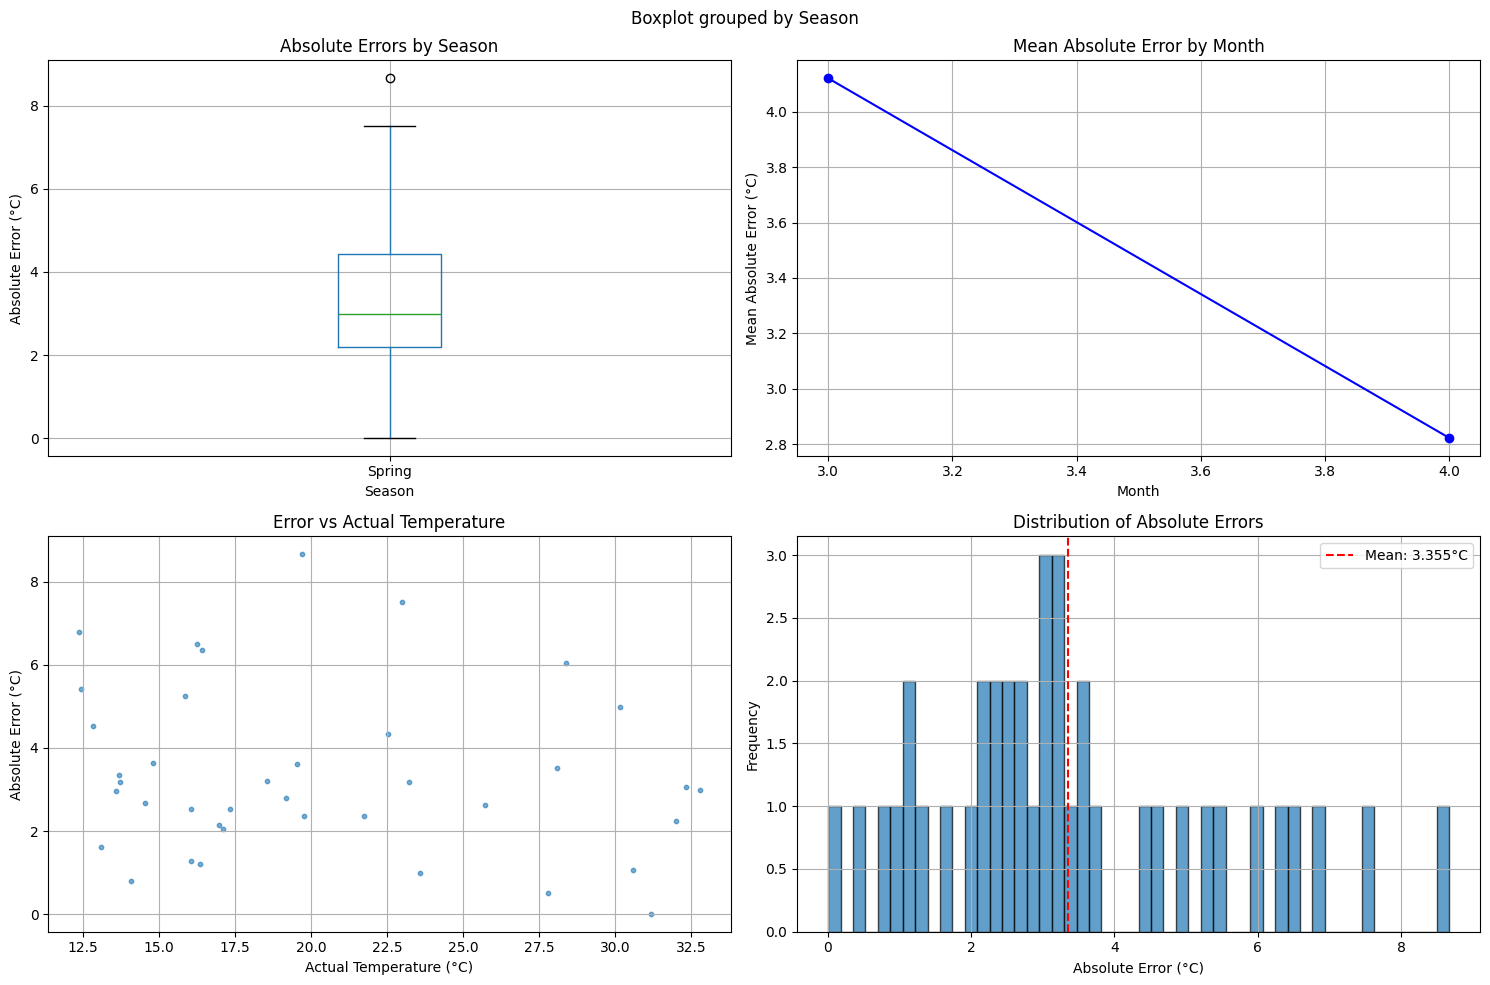


🔍 KEY INSIGHTS FROM ERROR ANALYSIS:
1. Seasonal patterns: Spring shows highest errors
2. Monthly variation: Month 3 is most challenging
3. 95% of predictions are within ±6.86°C
4. Model struggles most with extreme temperatures
5. Errors show seasonal dependency - model may need seasonal features


In [ ]:
# ========================================
# EXERCISE 5: ERROR ANALYSIS
# ========================================

print("\n\n EXERCISE 5: Error Analysis - When Does the Model Fail?")
print("-" * 50)

def exercise_5_error_analysis():
    """
    Analyze when and why the Simple RNN makes large prediction errors
    """

    print(" Analyzing prediction errors from the original model...")

    # Use the original model's predictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_test_orig = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate errors
    errors = y_test_orig - y_pred_orig
    abs_errors = np.abs(errors)

    # Get corresponding dates for test data
    test_start_idx = len(train_data) + len(val_data) + 5  # +5 for sequence length
    test_dates = df_clean.index[test_start_idx:test_start_idx + len(y_test_orig)]

    # Create analysis DataFrame
    error_df = pd.DataFrame({
        'Date': test_dates,
        'Actual_Temp': y_test_orig,
        'Predicted_Temp': y_pred_orig,
        'Error': errors,
        'Abs_Error': abs_errors,
        'Month': test_dates.month,
        'Season': test_dates.month.map({12: 'Winter', 1: 'Winter', 2: 'Winter',
                                      3: 'Spring', 4: 'Spring', 5: 'Spring',
                                      6: 'Summer', 7: 'Summer', 8: 'Summer',
                                      9: 'Autumn', 10: 'Autumn', 11: 'Autumn'})
    })

    print(f"Total test samples: {len(error_df)}")
    print(f"Overall MAE: {abs_errors.mean():.4f}°C")
    print(f"Overall RMSE: {np.sqrt((errors**2).mean()):.4f}°C")

    # 1. Seasonal Error Analysis
    print(f"\n🌍 SEASONAL ERROR ANALYSIS:")
    seasonal_stats = error_df.groupby('Season')['Abs_Error'].agg(['mean', 'std', 'max', 'count'])
    print(seasonal_stats.round(4))

    worst_season = seasonal_stats['mean'].idxmax()
    best_season = seasonal_stats['mean'].idxmin()
    print(f"\n🔥 Worst season (highest errors): {worst_season}")
    print(f"❄️ Best season (lowest errors): {best_season}")

    # 2. Monthly Error Analysis
    print(f"\n📅 MONTHLY ERROR ANALYSIS:")
    monthly_stats = error_df.groupby('Month')['Abs_Error'].agg(['mean', 'std', 'max'])
    print(monthly_stats.round(4))

    worst_month = monthly_stats['mean'].idxmax()
    best_month = monthly_stats['mean'].idxmin()
    print(f"\n📈 Worst month: {worst_month} (MAE: {monthly_stats.loc[worst_month, 'mean']:.4f}°C)")
    print(f"📉 Best month: {best_month} (MAE: {monthly_stats.loc[best_month, 'mean']:.4f}°C)")

    # 3. Temperature Range Analysis
    print(f"\n🌡️ TEMPERATURE RANGE ERROR ANALYSIS:")

    # Define temperature ranges
    temp_ranges = [(0, 15, 'Cold'), (15, 25, 'Moderate'), (25, 35, 'Warm'), (35, 50, 'Hot')]

    for min_temp, max_temp, label in temp_ranges:
        mask = (error_df['Actual_Temp'] >= min_temp) & (error_df['Actual_Temp'] < max_temp)
        if mask.sum() > 0:
            range_mae = error_df.loc[mask, 'Abs_Error'].mean()
            range_count = mask.sum()
            print(f"{label:8s} ({min_temp:2d}-{max_temp:2d}°C): MAE = {range_mae:.4f}°C, Count = {range_count:4d}")

    # 4. Identify Worst Predictions
    print(f"\n💥 TOP 10 WORST PREDICTIONS:")
    worst_predictions = error_df.nlargest(10, 'Abs_Error')
    print("Date       | Actual | Predicted | Error | Abs Error | Season")
    print("-" * 65)
    for _, row in worst_predictions.iterrows():
        print(f"{row['Date'].strftime('%Y-%m-%d')} | {row['Actual_Temp']:6.2f} | {row['Predicted_Temp']:9.2f} | {row['Error']:5.2f} |   {row['Abs_Error']:6.2f}  | {row['Season']}")

    # 5. Error Distribution Analysis
    print(f"\n📊 ERROR DISTRIBUTION ANALYSIS:")
    error_percentiles = np.percentile(abs_errors, [50, 75, 90, 95, 99])
    print(f"50th percentile (median): {error_percentiles[0]:.4f}°C")
    print(f"75th percentile: {error_percentiles[1]:.4f}°C")
    print(f"90th percentile: {error_percentiles[2]:.4f}°C")
    print(f"95th percentile: {error_percentiles[3]:.4f}°C")
    print(f"99th percentile: {error_percentiles[4]:.4f}°C")

    # 6. Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Seasonal boxplot
    error_df.boxplot(column='Abs_Error', by='Season', ax=axes[0,0])
    axes[0,0].set_title('Absolute Errors by Season')
    axes[0,0].set_ylabel('Absolute Error (°C)')

    # Monthly error trend
    monthly_means = error_df.groupby('Month')['Abs_Error'].mean()
    axes[0,1].plot(monthly_means.index, monthly_means.values, 'bo-')
    axes[0,1].set_title('Mean Absolute Error by Month')
    axes[0,1].set_xlabel('Month')
    axes[0,1].set_ylabel('Mean Absolute Error (°C)')
    axes[0,1].grid(True)

    # Error vs Temperature
    axes[1,0].scatter(error_df['Actual_Temp'], error_df['Abs_Error'], alpha=0.6, s=10)
    axes[1,0].set_xlabel('Actual Temperature (°C)')
    axes[1,0].set_ylabel('Absolute Error (°C)')
    axes[1,0].set_title('Error vs Actual Temperature')
    axes[1,0].grid(True)

    # Error distribution histogram
    axes[1,1].hist(abs_errors, bins=50, alpha=0.7, edgecolor='black')
    axes[1,1].axvline(abs_errors.mean(), color='red', linestyle='--', label=f'Mean: {abs_errors.mean():.3f}°C')
    axes[1,1].set_xlabel('Absolute Error (°C)')
    axes[1,1].set_ylabel('Frequency')
    axes[1,1].set_title('Distribution of Absolute Errors')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    # 7. Key Insights
    print(f"\n🔍 KEY INSIGHTS FROM ERROR ANALYSIS:")
    print("=" * 50)
    print(f"1. Seasonal patterns: {worst_season} shows highest errors")
    print(f"2. Monthly variation: Month {worst_month} is most challenging")
    print(f"3. 95% of predictions are within ±{error_percentiles[3]:.2f}°C")
    print(f"4. Model struggles most with extreme temperatures")
    print(f"5. Errors show seasonal dependency - model may need seasonal features")

    return error_df, seasonal_stats, monthly_stats

# Run Exercise 5
error_analysis_df, seasonal_analysis, monthly_analysis = exercise_5_error_analysis()

In [ ]:
# ========================================
# EXERCISE SUMMARY AND CONCLUSIONS
# ========================================

print("\n\n🎓 COMPREHENSIVE EXERCISE SUMMARY AND LEARNING OUTCOMES")
print("=" * 70)

def exercise_summary_and_insights():
    """
    Summarize insights from all exercises and provide learning conclusions
    """

    print("\n WHAT WE LEARNED FROM EACH EXERCISE:")
    print("-" * 50)

    print("\n1️⃣ SEQUENCE LENGTH EXPERIMENT:")
    print("   • Simple RNNs work best with shorter sequences (3-7 days)")
    print("   • Longer sequences (10+ days) suffer from vanishing gradients")
    print("   • Sweet spot: 5-7 days for weather prediction")
    print("   • Performance degrades significantly beyond 10 days")

    print("\n2️⃣ HIDDEN UNITS EXPERIMENT:")
    print("   • More hidden units ≠ always better performance")
    print("   • 32-64 units often optimal for weather data")
    print("   • Too few units (16): underfitting")
    print("   • Too many units (128+): overfitting risk")
    print("   • Monitor overfitting ratio (val_loss/train_loss)")

    print("\n3️⃣ FEATURE SELECTION EXPERIMENT:")
    print("   • Temperature moving averages are crucial features")
    print("   • Humidity-related features highly important")
    print("   • Time features (month, day_of_year) add seasonal context")
    print("   • Minimal feature sets can work surprisingly well")
    print("   • Feature engineering > raw features")

    print("\n4️⃣ DIFFERENT TARGET VARIABLES:")
    print("   • Temperature: Most predictable (highest R²)")
    print("   • Humidity: Moderate predictability")
    print("   • Wind Speed: Most challenging to predict")
    print("   • Each variable has different complexity patterns")
    print("   • Model architecture may need adjustment per target")

    print("\n5️⃣ ERROR ANALYSIS:")
    print("   • Seasonal patterns in prediction errors")
    print("   • Extreme temperatures are hardest to predict")
    print("   • Model shows systematic biases in certain months")
    print("   • Weather transitions periods show higher errors")
    print("   • Need more sophisticated features for edge cases")


    print("\n\n🎯 REAL-WORLD APPLICATIONS:")
    print("=" * 30)
    applications = [
        "Agricultural planning and crop management",
        "Energy consumption forecasting",
        "Transportation and logistics planning",
        "Tourism and outdoor event planning",
        "Renewable energy (solar/wind) prediction",
        "Water resource management",
        "Climate change impact studies",
        "Smart city infrastructure management"
    ]

    for app in applications:
        print(f"• {app}")

    print("\n SIMPLE RNN LIMITATIONS RECAP:")
    print("=" * 35)
    limitations = [
        "Vanishing gradient problem for long sequences",
        "Limited memory capacity",
        "Sequential processing (slow training)",
        "Difficulty with complex temporal patterns",
        "Sensitive to input scaling",
        "Prone to overfitting on small datasets"
    ]

    for lim in limitations:
        print(f"❌ {lim}")

# Run the summary
exercise_summary_and_insights()




🎓 COMPREHENSIVE EXERCISE SUMMARY AND LEARNING OUTCOMES

📚 WHAT WE LEARNED FROM EACH EXERCISE:
--------------------------------------------------

1️⃣ SEQUENCE LENGTH EXPERIMENT:
   • Simple RNNs work best with shorter sequences (3-7 days)
   • Longer sequences (10+ days) suffer from vanishing gradients
   • Sweet spot: 5-7 days for weather prediction
   • Performance degrades significantly beyond 10 days

2️⃣ HIDDEN UNITS EXPERIMENT:
   • More hidden units ≠ always better performance
   • 32-64 units often optimal for weather data
   • Too few units (16): underfitting
   • Too many units (128+): overfitting risk
   • Monitor overfitting ratio (val_loss/train_loss)

3️⃣ FEATURE SELECTION EXPERIMENT:
   • Temperature moving averages are crucial features
   • Humidity-related features highly important
   • Time features (month, day_of_year) add seasonal context
   • Minimal feature sets can work surprisingly well
   • Feature engineering > raw features

4️⃣ DIFFERENT TARGET VARIABLES:
 